In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.animation as animation
import matplotlib.cm as cm
from matplotlib.patches import Rectangle
from tqdm import tqdm
from PIL import Image
import os
import gc
import warnings
from funcs import *
import cupy as cp

def _to_numpy(array):
    return cp.asnumpy(array) if isinstance(array, cp.ndarray) else np.asarray(array)

%matplotlib inline
warnings.filterwarnings('ignore')

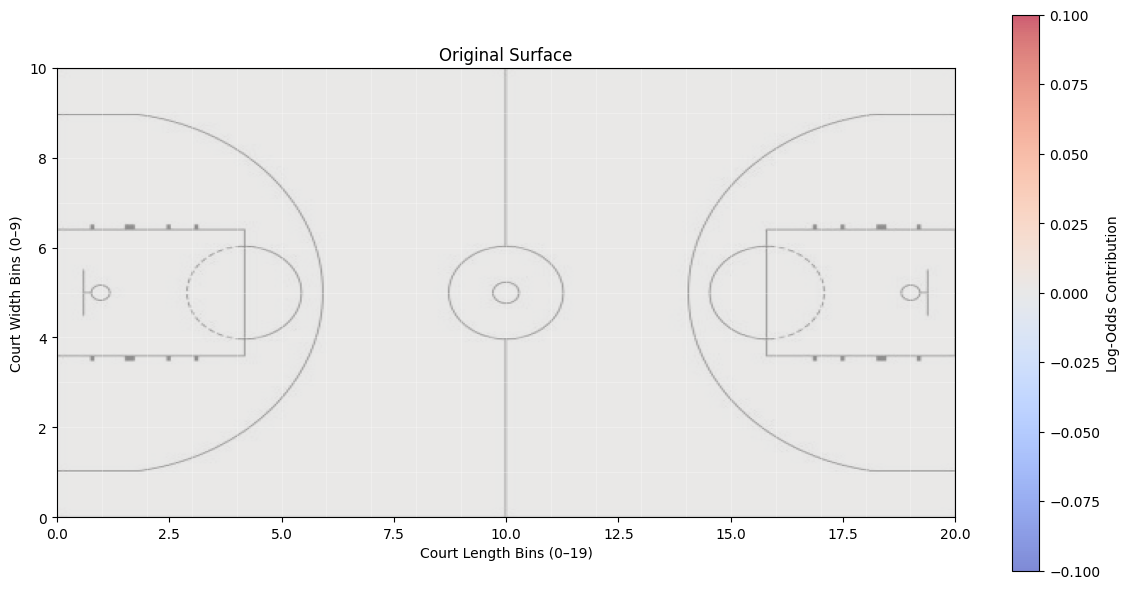

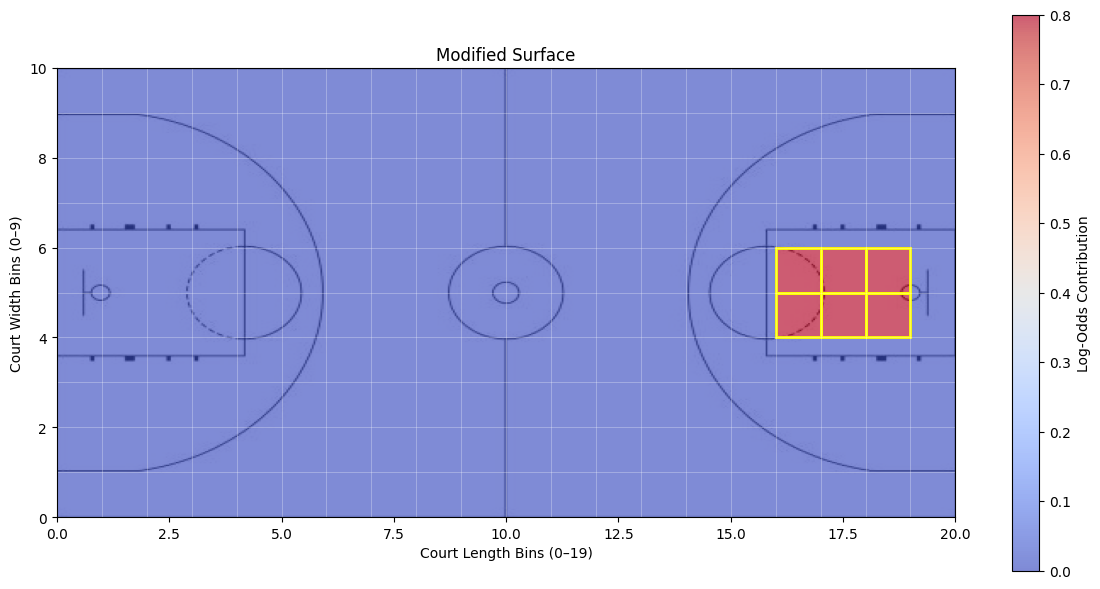

In [2]:
# -------------------------------------------------
# COURT SETTINGS
# -------------------------------------------------

x_bins = 20
y_bins = 10

court_img = Image.open("court.jpg")

# -------------------------------------------------
# 1. CREATE BLANK LOG-ODDS MATRIX
# -------------------------------------------------

# Each cell represents a sector's contribution to scoring log-odds
propensity_matrix = cp.zeros((x_bins, y_bins))

# -------------------------------------------------
# 2. FUNCTION TO MODIFY SECTORS
# -------------------------------------------------

def build_range_updates(length_range, width_range, value):
    x_start, x_end = length_range
    y_start, y_end = width_range

    return {
        (x, y): value
        for x in range(x_start, x_end + 1)
        for y in range(y_start, y_end + 1)
    }


def adjust_sector_propensity(matrix, updates, mode="add"):
    
    new_matrix = matrix.copy()

    for (x, y), value in updates.items():

        if mode == "add":
            new_matrix[x, y] += value

        elif mode == "set":
            new_matrix[x, y] = value

        else:
            raise ValueError("mode must be 'add' or 'set'")

    return new_matrix


# -------------------------------------------------
# 3. PLOT FUNCTION
# -------------------------------------------------

def plot_surface(matrix, title="Sector Log-Odds Surface", changed=None):

    fig, ax = plt.subplots(figsize=(12,6))

    ax.imshow(court_img, extent=[0,x_bins,0,y_bins], aspect="auto")

    matrix_np = _to_numpy(matrix)

    img = ax.imshow(
        matrix_np.T,
        origin="lower",
        cmap="coolwarm",
        extent=[0,x_bins,0,y_bins],
        alpha=0.65
    )

    # grid lines
    for x in range(x_bins+1):
        ax.axvline(x,color="white",lw=0.5,alpha=0.4)

    for y in range(y_bins+1):
        ax.axhline(y,color="white",lw=0.5,alpha=0.4)

    # highlight changed sectors
    if changed is not None:
        for (x,y) in changed:
            rect = Rectangle((x,y),1,1,
                             fill=False,
                             edgecolor="yellow",
                             lw=2)
            ax.add_patch(rect)

    plt.colorbar(img, ax=ax, label="Log-Odds Contribution")

    ax.set_xlim(0,x_bins)
    ax.set_ylim(0,y_bins)

    ax.set_title(title)
    ax.set_xlabel("Court Length Bins (0–19)")
    ax.set_ylabel("Court Width Bins (0–9)")

    plt.tight_layout()
    plt.show()


# -------------------------------------------------
# 4. EXAMPLE: BATCH MODIFY A RANGE OF SECTORS
# -------------------------------------------------

length_range = (16, 18)
width_range = (4, 5)
value = 0.8

updates = build_range_updates(length_range, width_range, value)

modified_matrix = adjust_sector_propensity(
    propensity_matrix,
    updates,
    mode="set"
)

# -------------------------------------------------
# 5. PLOT ORIGINAL AND MODIFIED
# -------------------------------------------------

plot_surface(propensity_matrix, "Original Surface")

plot_surface(modified_matrix,
             "Modified Surface",
             changed=updates.keys())

# Example for multiple batch updates:
# updates = {}
# updates.update(build_range_updates((16, 18), (4, 5), 0.8))
# updates.update(build_range_updates((18, 19), (2, 3), -0.4))

In [3]:
# Adjust the matrix for time, and move hot/cold sectors around
# Create fake games, ~100 samples per game
# Simulate where they scored or not, adjust danger zones to reflect the actual scoring rate
# Play with matrix to reflect actual scoring
# Sectors increase likelihood of scoring
# Check out Codex

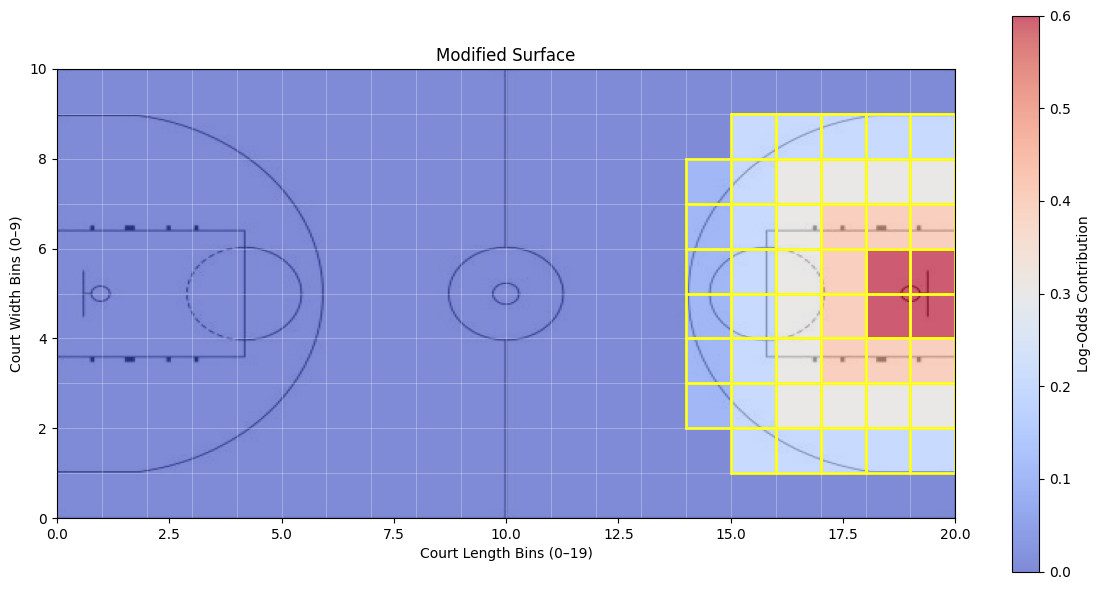

In [4]:
updates = {}

def wrap(x_1, x_2, y_1, y_2, val ,square):
    global modified_matrix

    updates.update(build_range_updates((x_1, x_1), (y_1, y_2), val))

    if (square == True): 
        updates.update(build_range_updates((x_2, x_2), (y_1, y_2), val))

    updates.update(build_range_updates((x_1, x_2), (y_1, y_1), val))
    updates.update(build_range_updates((x_1, x_2), (y_2, y_2), val))

    #return modified_matrix
    
updates.update(build_range_updates((18, 19), (4, 5), .6))
updates.update(build_range_updates((14, 14), (2, 7), .1))
wrap(17, 19, 3, 6, .4, False)
wrap(16, 19, 2, 7, .3, False)
wrap(15, 19, 1, 8, .2, False)

modified_matrix = adjust_sector_propensity(
    propensity_matrix,
    updates,
    mode="set"
    )

plot_surface(modified_matrix,
         "Modified Surface",
         changed=updates.keys())

In [5]:
df = pd.read_csv("multi_game_data.csv")

def build_visited_bin_matrices(df, x_bins=20, y_bins=10):
    required_cols = {"game_id", "possession_number", "x_bin", "y_bin", "scored"}
    missing_cols = required_cols.difference(df.columns)

    if missing_cols:
        raise ValueError(f"df is missing required columns: {sorted(missing_cols)}")

    records = []

    grouped = df.groupby(["game_id", "possession_number"], sort=True)
    for (game_id, possession_number), group in grouped:
        # Matrix shape is (x_bins, y_bins): x is the first axis, y is the second.
        visited_matrix = cp.zeros((x_bins, y_bins), dtype=cp.int8)
        visited_bins = set(zip(group["x_bin"].astype(int), group["y_bin"].astype(int)))

        for xb, yb in visited_bins:
            if 0 <= xb < x_bins and 0 <= yb < y_bins:
                visited_matrix[xb, yb] = 1

        records.append({
            "game_id": game_id,
            "possession_number": possession_number,
            "scored": int(group["scored"].iloc[0]),
            "visited_matrix": visited_matrix
        })

    return pd.DataFrame(records)


visited_bin_matrices = build_visited_bin_matrices(df, x_bins=x_bins, y_bins=y_bins)

# Shape: (n_possessions, x_bins, y_bins)
possession_game_bin_matrix = cp.stack(visited_bin_matrices["visited_matrix"].to_list())

# Flatten each possession matrix into one design row while preserving x-by-y order.
X = possession_game_bin_matrix.reshape(len(visited_bin_matrices), -1)

# Outcome vector aligned with the stacked possession matrices and flattened design rows.
y = cp.asarray(visited_bin_matrices["scored"].to_numpy(dtype=np.int8))


In [6]:
def sample_X_y(X, y, n_samples, replace=True, random_state=None):
    if len(X) != len(y):
        raise ValueError(f"X has {len(X)} rows but y has length {len(y)}")

    rng = cp.random.RandomState(random_state)
    sample_idx = rng.choice(len(X), size=n_samples, replace=replace)

    return X[sample_idx], y[sample_idx], sample_idx

X_sample, y_sample, sample_idx = sample_X_y(X, y, n_samples=95, random_state=42)

print("stacked matrix shape:", possession_game_bin_matrix.shape)
print("flattened design shape:", X.shape)
print("outcome shape:", y.shape)
print("sample indices:", sample_idx)

X_sample, y_sample

stacked matrix shape: (902, 20, 10)
flattened design shape: (902, 200)
outcome shape: (902,)
sample indices: [ 39 772  54  62  96 658 162 156 249 309 871 853 125 192 412 293 654 448
 293 623 146 265 663  64  10 697 109 616 805 809 264 410 361 712 570 886
 170  68 700 459 816 499 585 566 181 521 319 445 314 393 236 455 438  75
 556 341 468 864 491  52 279 113 900 635 354 807  49 739 421 442 484  31
  89  94 567 640 215 239 171 602 298 709 417 179 593  90 827   8 805 142
 154 847 829 368 308]


(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(95, 200), dtype=int8),
 array([1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1,
        0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1,
        1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1,
        1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0,
        1, 0, 1, 1, 1, 1, 1], dtype=int8))

In [7]:
# Flatten betas in the same x-by-y order used to build each row of X.
betas = modified_matrix.reshape(-1)

if X.shape[1] != betas.shape[0]:
    raise ValueError(
        f"X has {X.shape[1]} columns but betas has length {betas.shape[0]}"
    )

logits = X_sample @ betas
propensity_scores = 1 / (1 + cp.exp(-logits))

print("X shape:", X.shape)
print("betas shape:", betas.shape)
print("logits shape:", logits.shape)
print("propensity_scores shape:", propensity_scores.shape)

# Avoid above, use below:
# heuristically instead
# baseline: no score
# depending on position, will increase or decrease score
# start with where the play ended, move to full movement
# use proportion of movements in specific zones

X shape: (902, 200)
betas shape: (200,)
logits shape: (95,)
propensity_scores shape: (95,)


In [8]:
propensity_scores

array([0.9900482 , 0.99797468, 0.99917558, 0.99183743, 0.57444252,
       0.97340301, 0.94267582, 0.92414182, 0.99888746, 0.62245933,
       0.99797468, 0.90887704, 0.98787157, 0.9909867 , 0.99986363,
       0.96442881, 0.88079708, 0.9950332 , 0.96442881, 0.98015969,
       0.549834  , 0.99776215, 0.99592986, 0.97068777, 0.99925397,
       0.62245933, 0.99183743, 0.9836975 , 0.99797468, 0.93086158,
       0.96770454, 0.99550373, 0.98661308, 0.99550373, 0.99592986,
       0.90024951, 0.96083428, 0.73105858, 0.99631576, 0.9836975 ,
       0.99797468, 0.99864148, 0.92414182, 0.99797468, 0.549834  ,
       0.99183743, 0.98787157, 0.73105858, 0.99183743, 0.9987706 ,
       0.99959043, 0.68997448, 0.9939402 , 0.98201379, 0.99550373,
       0.99932492, 0.5       , 0.96083428, 0.97340301, 0.99592986,
       0.99888746, 0.98901306, 0.97811873, 0.98661308, 0.99752738,
       0.9994998 , 0.99183743, 0.99966465, 0.98787157, 0.5       ,
       0.81757448, 0.99183743, 0.99183743, 0.9836975 , 0.98369

In [9]:
#Shelf this for now, develop heuristic method first

In [10]:
cleaned = pd.read_csv("multi_game_data/multi_game_data_half_court_filtered.csv")

In [11]:
cleaned

,game_id,home_away,is_home,period,time,x,y,z,possession_start,possession_end,possession_number,scored,half_court_crossings
0,21500009,home,1,1,719.00,37.04728,15.02163,6.44393,720.0,703.0,1.0,1.0,1
1,21500009,home,1,1,718.96,36.30142,14.70948,6.12091,720.0,703.0,1.0,1.0,1
2,21500009,home,1,1,718.92,35.67854,14.33637,5.70189,720.0,703.0,1.0,1.0,1
3,21500009,home,1,1,718.88,34.84530,13.68251,5.15255,720.0,703.0,1.0,1.0,1
4,21500009,home,1,1,718.84,34.18749,13.55080,4.64143,720.0,703.0,1.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
701940,21500649,home,1,4,21.10,83.69121,22.79488,4.07905,34.0,21.0,86.0,1.0,1
701941,21500649,home,1,4,21.10,83.47899,23.10999,3.94410,34.0,21.0,86.0,1.0,1
701942,21500649,home,1,4,21.10,83.28644,23.44933,3.79860,34.0,21.0,86.0,1.0,1
701943,21500649,home,1,4,21.10,83.13118,23.82744,3.63053,34.0,21.0,86.0,1.0,1


In [12]:
cleaned_binned = bin_and_flip(cleaned, flip = "yes")
cleaned_binned["sector"] = list(zip(cleaned_binned["x_bin"], cleaned_binned["y_bin"]))
cleaned_binned

,game_id,home_away,is_home,period,time,x,y,z,possession_start,possession_end,possession_number,scored,half_court_crossings,x_bin,y_bin,sector
0,21500009,home,1,1,719.00,37.04728,15.02163,6.44393,720.0,703.0,1.0,1.0,1,7,3,"(7, 3)"
1,21500009,home,1,1,718.96,36.30142,14.70948,6.12091,720.0,703.0,1.0,1.0,1,7,2,"(7, 2)"
2,21500009,home,1,1,718.92,35.67854,14.33637,5.70189,720.0,703.0,1.0,1.0,1,7,2,"(7, 2)"
3,21500009,home,1,1,718.88,34.84530,13.68251,5.15255,720.0,703.0,1.0,1.0,1,7,2,"(7, 2)"
4,21500009,home,1,1,718.84,34.18749,13.55080,4.64143,720.0,703.0,1.0,1.0,1,7,2,"(7, 2)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
701940,21500649,home,1,4,21.10,83.69121,22.79488,4.07905,34.0,21.0,86.0,1.0,1,17,4,"(17, 4)"
701941,21500649,home,1,4,21.10,83.47899,23.10999,3.94410,34.0,21.0,86.0,1.0,1,17,4,"(17, 4)"
701942,21500649,home,1,4,21.10,83.28644,23.44933,3.79860,34.0,21.0,86.0,1.0,1,17,4,"(17, 4)"
701943,21500649,home,1,4,21.10,83.13118,23.82744,3.63053,34.0,21.0,86.0,1.0,1,17,4,"(17, 4)"


In [13]:
possession_cols = ["game_id", "possession_number"]


def build_visited_possessions(
    binned_df,
    possession_cols=possession_cols,
    sector_col="sector",
    scored_col="scored",
    sample_interval_seconds=0.04,
    last_n_unique_visited=5,
):
    required_cols = set(possession_cols) | {sector_col, scored_col}
    missing_cols = required_cols.difference(binned_df.columns)
    if missing_cols:
        raise ValueError(f"binned_df is missing required columns: {sorted(missing_cols)}")

    visited = binned_df.groupby(possession_cols, observed=False)[sector_col].value_counts().reset_index()
    visited["time"] = visited["count"] * sample_interval_seconds
    visited["time_proportion"] = (
        visited["count"]
        / visited.groupby(possession_cols, observed=False)["count"].transform("sum")
    )

    possession_scoring = (
        binned_df.groupby(possession_cols, observed=False)[scored_col].max().reset_index()
    )
    visited = visited.merge(possession_scoring, on=possession_cols, how="left")

    end_sector = (
        binned_df.drop_duplicates(possession_cols, keep="last")
        .assign(is_end_sector=True)[possession_cols + [sector_col, "is_end_sector"]]
    )
    visited = visited.merge(end_sector, on=possession_cols + [sector_col], how="left")
    visited["is_end_sector"] = visited["is_end_sector"].eq(True)

    last_visited_col = f"was_last_{last_n_unique_visited}_visited"
    last_visited = (
        binned_df.drop_duplicates(possession_cols + [sector_col], keep="last")
        .groupby(possession_cols, observed=False)
        .tail(last_n_unique_visited)
        .assign(**{last_visited_col: True})[possession_cols + [sector_col, last_visited_col]]
    )
    visited = visited.merge(last_visited, on=possession_cols + [sector_col], how="left")
    visited[last_visited_col] = visited[last_visited_col].eq(True)

    return visited


def _sector_effect_lookup(sector, effects):
    if effects is None:
        return 0.0

    if isinstance(effects, dict):
        return effects.get(sector, 0.0)

    x_bin, y_bin = sector
    if 0 <= x_bin < effects.shape[0] and 0 <= y_bin < effects.shape[1]:
        if isinstance(effects, cp.ndarray):
            return float(effects[x_bin, y_bin].get())
        return effects[x_bin, y_bin]

    return 0.0


def create_baseline_scoring_probabilities(
    visited_possessions,
    movement_effects=None,
    end_effects=None,
    baseline_probability=None,
    possession_cols=("game_id", "possession_number"),
    sector_col="sector",
    movement_weight_col=None,
    end_indicator_col="is_end_sector",
    scored_col="scored",
):
    required_cols = set(possession_cols) | {sector_col}
    if movement_weight_col is not None:
        required_cols.add(movement_weight_col)
    missing_cols = required_cols.difference(visited_possessions.columns)
    if missing_cols:
        raise ValueError(f"visited_possessions is missing required columns: {sorted(missing_cols)}")

    df = visited_possessions.copy()

    if baseline_probability is None:
        if scored_col not in df.columns:
            raise ValueError("Provide baseline_probability or include a scored column.")
        baseline_probability = df.groupby(list(possession_cols), observed=False)[scored_col].max().mean()

    baseline_probability = np.clip(baseline_probability, 0, 1)
    df["movement_sector_effect"] = df[sector_col].apply(
        lambda sector: _sector_effect_lookup(sector, movement_effects)
    )
    if movement_weight_col is None:
        df["movement_probability_adjustment"] = df["movement_sector_effect"]
    else:
        df["movement_probability_adjustment"] = df["movement_sector_effect"] * df[movement_weight_col]

    if end_indicator_col in df.columns:
        df["end_sector_effect"] = df[sector_col].apply(
            lambda sector: _sector_effect_lookup(sector, end_effects)
        )
        df["end_probability_adjustment"] = np.where(df[end_indicator_col], df["end_sector_effect"], 0.0)
    else:
        df["end_probability_adjustment"] = 0.0

    probability_components = (
        df.groupby(list(possession_cols), observed=False)
        .agg(
            movement_probability_adjustment=("movement_probability_adjustment", "sum"),
            end_probability_adjustment=("end_probability_adjustment", "sum"),
        )
        .reset_index()
    )

    probability_components["movement_probability_adjustment"] = (
        probability_components["movement_probability_adjustment"].round(10)
    )
    probability_components["baseline_probability"] = baseline_probability
    probability_components["raw_scoring_probability"] = (
        probability_components["baseline_probability"]
        + probability_components["movement_probability_adjustment"]
        + probability_components["end_probability_adjustment"]
    )
    probability_components["scoring_probability"] = probability_components["raw_scoring_probability"].clip(0, 1)

    if scored_col in df.columns:
        actual_scoring = df.groupby(list(possession_cols), observed=False)[scored_col].max().reset_index()
        probability_components = probability_components.merge(actual_scoring, on=list(possession_cols), how="left")

    return probability_components


def plot_effect_surfaces(
    movement_effects,
    end_effects,
    court_image_path="court.jpg",
    x_bins=x_bins,
    y_bins=y_bins,
    title_prefix="Pipeline",
):
    effect_maps = [_to_numpy(movement_effects), _to_numpy(end_effects)]
    titles = [f"{title_prefix} Movement Effects", f"{title_prefix} End Effects"]
    v_abs = max(float(np.nanmax(np.abs(effect))) for effect in effect_maps)
    v_abs = v_abs if v_abs > 0 else 1.0

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
    court = Image.open(court_image_path) if court_image_path is not None else None

    for ax, effect, title in zip(axes, effect_maps, titles):
        if court is not None:
            ax.imshow(court, extent=[0, x_bins, 0, y_bins], aspect="auto")

        im = ax.imshow(
            effect.T,
            origin="lower",
            extent=[0, x_bins, 0, y_bins],
            cmap="coolwarm",
            alpha=0.75,
            vmin=-v_abs,
            vmax=v_abs,
        )

        for x in range(x_bins + 1):
            ax.axvline(x, color="white", lw=0.5, alpha=0.35)
        for y in range(y_bins + 1):
            ax.axhline(y, color="white", lw=0.5, alpha=0.35)

        ax.set_xlim(0, x_bins)
        ax.set_ylim(0, y_bins)
        ax.set_title(title)
        ax.set_xlabel("x_bin")
        ax.set_ylabel("y_bin")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Probability Adjustment")

    plt.show()


def sample_possessions_from_games(
    df,
    game_ids,
    n_possessions,
    possession_cols=possession_cols,
    random_state=None,
    reindex_possessions=True,
):
    game_col, possession_col = possession_cols
    game_df = df[df[game_col].isin(game_ids)].copy()
    possession_keys = game_df[possession_cols].drop_duplicates()

    if possession_keys.empty:
        raise ValueError("No possessions found for the requested game_ids.")

    replace = n_possessions > len(possession_keys)
    sampled_keys = possession_keys.sample(
        n=n_possessions,
        replace=replace,
        random_state=random_state,
    ).reset_index(drop=True)

    if reindex_possessions:
        sampled_keys = sampled_keys.assign(_sample_possession_number=lambda x: x.index)
        sampled = sampled_keys.merge(game_df, on=possession_cols, how="left")
        sampled["original_possession_number"] = sampled[possession_col]
        sampled[possession_col] = sampled["_sample_possession_number"]
        return sampled.drop(columns="_sample_possession_number")

    return game_df.merge(sampled_keys, on=possession_cols, how="inner")


def build_baseline_scoring_pipeline(
    df,
    train_games,
    n_possessions,
    movement_effects=None,
    end_effects=None,
    baseline_probability=0.50,
    random_state=None,
    flip="yes",
    movement_weight_col=None,
    reindex_possessions=True,
):
    sampled_movement = sample_possessions_from_games(
        df,
        game_ids=train_games,
        n_possessions=n_possessions,
        random_state=random_state,
        reindex_possessions=reindex_possessions,
    )
    sampled_binned_movement = bin_and_flip(sampled_movement, flip=flip)
    sampled_binned_movement["sector"] = list(
        zip(sampled_binned_movement["x_bin"], sampled_binned_movement["y_bin"])
    )

    sampled_visited_posssessions = build_visited_possessions(sampled_binned_movement)
    sampled_baseline_scoring_probabilities = create_baseline_scoring_probabilities(
        sampled_visited_posssessions,
        movement_effects=movement_effects,
        end_effects=end_effects,
        baseline_probability=baseline_probability,
        movement_weight_col=movement_weight_col,
    )

    return {
        "sampled_movement": sampled_movement,
        "sampled_binned_movement": sampled_binned_movement,
        "qut_movement": sampled_binned_movement,
        "visited_posssessions": sampled_visited_posssessions,
        "baseline_scoring_probabilities": sampled_baseline_scoring_probabilities,
    }


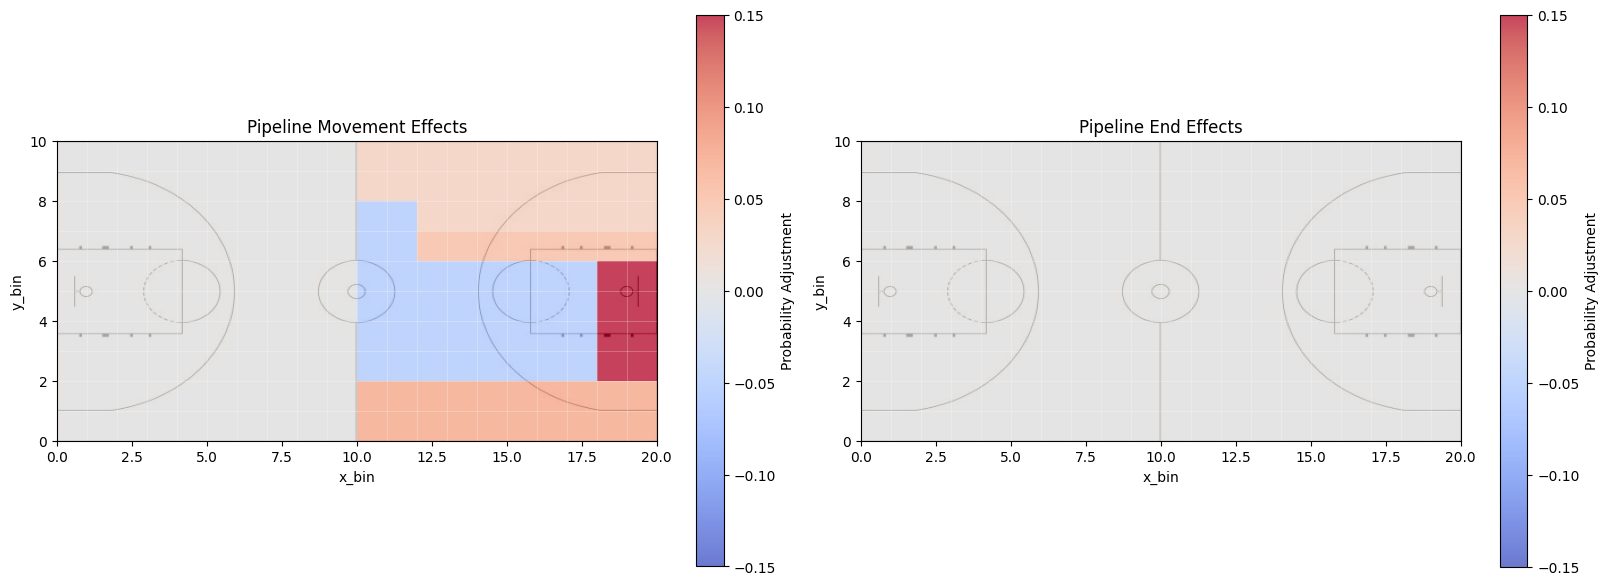

,game_id,possession_number,home_away,is_home,period,time,x,y,z,possession_start,possession_end,scored,half_court_crossings,original_possession_number,x_bin,y_bin,sector,simulated_out,original_scored
0,21500057,0,away,0,1,295.97,3.47142,30.55555,3.98793,296.0,286.0,0,1,15.0,0,6,"(0, 6)",0,0.0
1,21500057,0,away,0,1,295.93,2.84831,30.59214,4.81059,296.0,286.0,0,1,15.0,0,6,"(0, 6)",0,0.0
2,21500057,0,away,0,1,295.89,2.68523,30.55164,4.46575,296.0,286.0,0,1,15.0,0,6,"(0, 6)",0,0.0
3,21500057,0,away,0,1,295.85,2.36697,30.46828,4.34850,296.0,286.0,0,1,15.0,0,6,"(0, 6)",0,0.0
4,21500057,0,away,0,1,295.81,2.18673,30.44254,4.17210,296.0,286.0,0,1,15.0,0,6,"(0, 6)",0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431822,21500057,499,away,0,3,356.90,37.49427,48.84045,3.81579,360.0,342.0,0,1,62.0,7,9,"(7, 9)",0,0.0
431823,21500057,499,away,0,3,356.86,37.11865,49.48142,3.01859,360.0,342.0,0,1,62.0,7,9,"(7, 9)",0,0.0
431824,21500057,499,away,0,3,356.82,36.52002,47.94257,1.87418,360.0,342.0,0,1,62.0,7,9,"(7, 9)",0,0.0
431825,21500057,499,away,0,3,356.78,36.23990,47.13254,1.20747,360.0,342.0,0,1,62.0,7,9,"(7, 9)",0,0.0


,game_id,possession_number,movement_probability_adjustment,end_probability_adjustment,baseline_probability,raw_scoring_probability,scoring_probability,scored,simulated_out
0,21500009,5,-0.55,0.0,0.3,-0.25,0.00,0.0,0
1,21500009,7,-0.45,0.0,0.3,-0.15,0.00,0.0,0
2,21500009,14,0.05,0.0,0.3,0.35,0.35,1.0,1
3,21500009,33,-0.24,0.0,0.3,0.06,0.06,1.0,0
4,21500009,37,0.90,0.0,0.3,1.20,1.00,1.0,1
...,...,...,...,...,...,...,...,...,...
495,21500649,470,0.83,0.0,0.3,1.13,1.00,1.0,1
496,21500649,476,0.24,0.0,0.3,0.54,0.54,0.0,0
497,21500649,487,-0.04,0.0,0.3,0.26,0.26,1.0,0
498,21500649,488,0.27,0.0,0.3,0.57,0.57,0.0,0


In [20]:
pipeline_input_df = pd.read_csv("multi_game_data/multi_game_data_half_court_filtered.csv")

pipeline_seed = 42
train_set = [21500649, 21500390, 21500188, 21500355, 21500057, 21500009]

pipeline_movement_effects = np.zeros((x_bins, y_bins))
pipeline_end_effects = np.zeros((x_bins, y_bins))

pipeline_movement_effects[10:18, 0:3] = .07
pipeline_movement_effects[18:20, 0:3] = .07
pipeline_movement_effects[10:20, 6] = .05
pipeline_movement_effects[10:20, 7:10] = .03
pipeline_movement_effects[18:20, 2:6] = .15
pipeline_movement_effects[10:18, 2:6] = -.05
pipeline_movement_effects[10:12, 6:8] = -.05

plot_effect_surfaces(pipeline_movement_effects, pipeline_end_effects, title_prefix="Pipeline")

pipeline_results = build_baseline_scoring_pipeline(
    pipeline_input_df,
    train_games=train_set,
    n_possessions=500,
    movement_effects=pipeline_movement_effects,
    end_effects=pipeline_end_effects,
    baseline_probability=0.30,
    random_state=pipeline_seed,
)

pipeline_sampled_movement = pipeline_results["sampled_movement"]
pipeline_sampled_binned_movement = pipeline_results["sampled_binned_movement"]
pipeline_qut_movement = pipeline_results["qut_movement"]
pipeline_visited_posssessions = pipeline_results["visited_posssessions"]
pipeline_baseline_scoring_probabilities = pipeline_results["baseline_scoring_probabilities"]

visited_posssessions = pipeline_visited_posssessions
baseline_scoring_probabilities = pipeline_baseline_scoring_probabilities
pipeline_rng = np.random.default_rng(pipeline_seed)
baseline_scoring_probabilities["simulated_out"] = pipeline_rng.binomial(n=1, p=baseline_scoring_probabilities["scoring_probability"])

pipeline_simulated_scoring = baseline_scoring_probabilities[possession_cols + ["simulated_out"]]
pipeline_qut_movement = pipeline_qut_movement.merge(
    pipeline_simulated_scoring,
    on=possession_cols,
    how="left",
)
pipeline_qut_movement["original_scored"] = pipeline_qut_movement["scored"]
pipeline_qut_movement["scored"] = pipeline_qut_movement["simulated_out"]

display(pipeline_qut_movement)

display(baseline_scoring_probabilities)


In [19]:
#baseline_scoring_probabilities["simulated_out"].mean() #seeing if the scoring rate is similar to actaul games, .45 - .6 is acceptable
sum(pipeline_qut_movement["possession_start"] - pipeline_qut_movement["possession_end"])/len(pipeline_qut_movement)

17.855585180468783


=== Processing single ===


Generating Bootstrapped Datasets:   0%|          | 0/100 [00:00<?, ?it/s]

Generating Bootstrapped Datasets: 100%|██████████| 100/100 [05:13<00:00,  3.13s/it]


Simulating null responses...
Accepted 100 / 100 simulations
λ_qut (95th percentile null): 69.7695
λ_max (data): 998.5462


Computing λ_max for bootstraps: 100%|██████████| 99/99 [01:26<00:00,  1.15it/s]

λ_qut (95th percentile null): 69.7695
λ_max (observed): 998.5462
95% CI for λ_max (bootstrap): [921.4240, 1011.5445]
Empirical p-value (λ_max > λ_qut): 0.0000


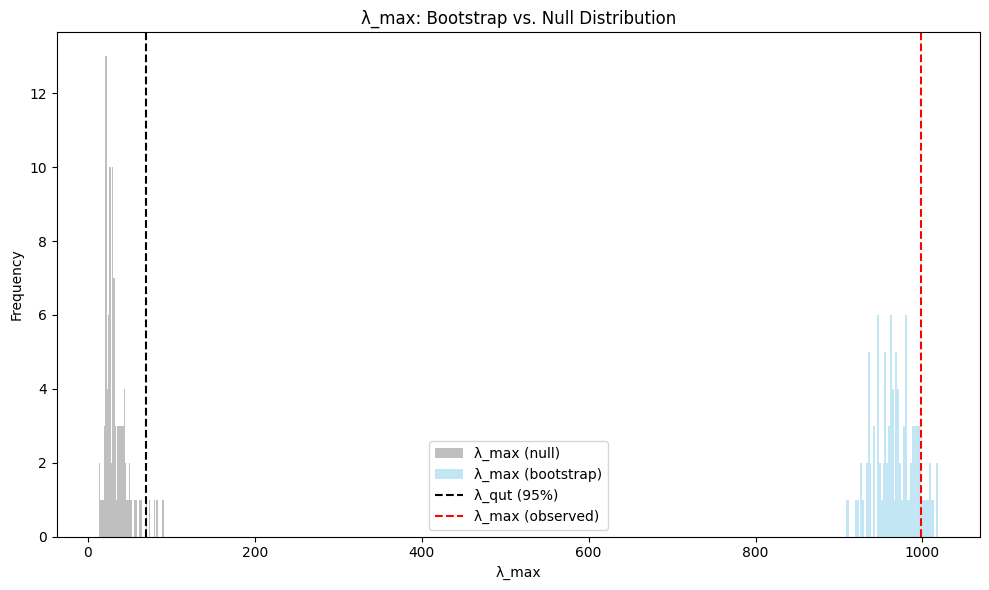

Bootstraps @ generated λ=69.77: 100%|██████████| 100/100 [03:21<00:00,  2.02s/it]


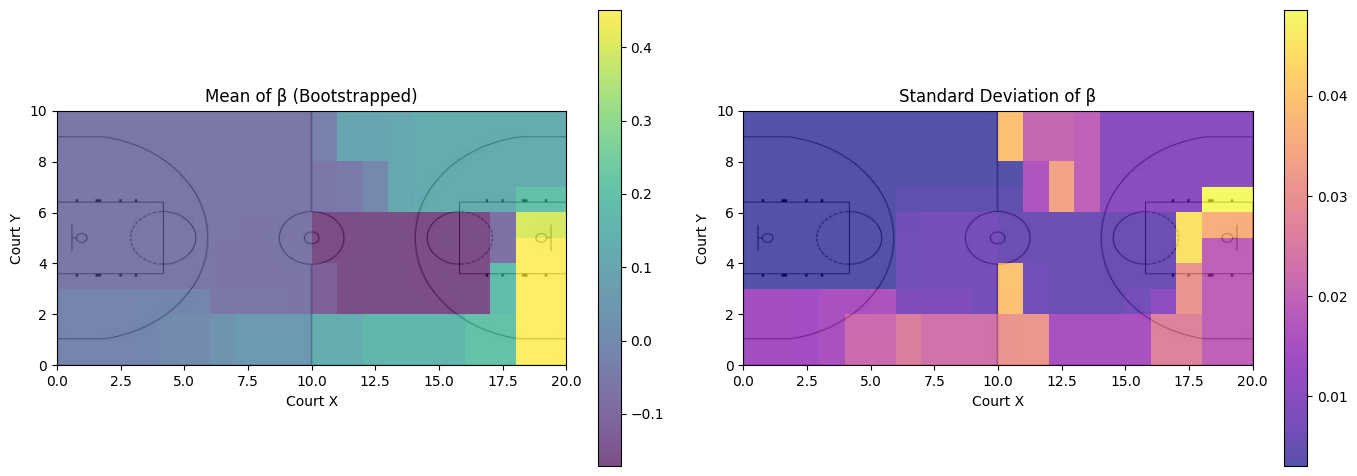

Plotting pointwise percentile maps at lambda = 69.7695


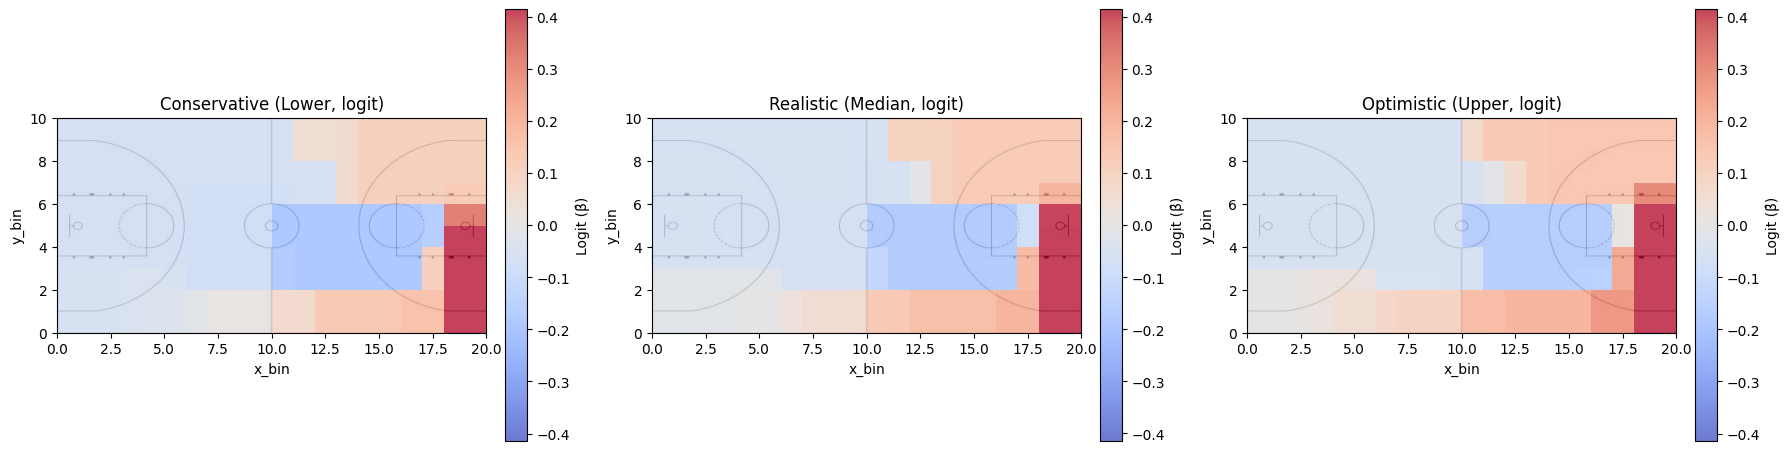

In [21]:
pipeline_n_bootstraps = 100
pipeline_mc_null = 100
pipeline_alpha = 0.05

pipeline_qut_results = analyze_tv_logistic_single_game(
    pipeline_qut_movement,
    game_id=None,
    n_bootstraps=pipeline_n_bootstraps,
    n_possessions=10000,
    samples_per_possession=50,
    min_samples_required=100,
    mc_null=pipeline_mc_null,
    alpha=pipeline_alpha,
    court_image_path="court.jpg",
    show_progress=True,
    plot_beta_summary=True,
    plot_pointwise_maps=True,
    plot_lambda_distributions=True,
    seed=pipeline_seed,
)

In [ ]:
# use on 0021500390 for projection
# show slack math
# four simulated: "expected", emphasis on one side (right), perimeter shooting, left side emphasis (minimal emphasis under basket)
# covariate player measurements
# brainstorm ways to compare simulation profile to bootstrapped profile